In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

plt.style.use('ggplot')

from matplotlib.pyplot import figure
from matplotlib.lines import Line2D

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# rading the data
df = pd.read_csv(
    r'../data/work_mode.csv'
)

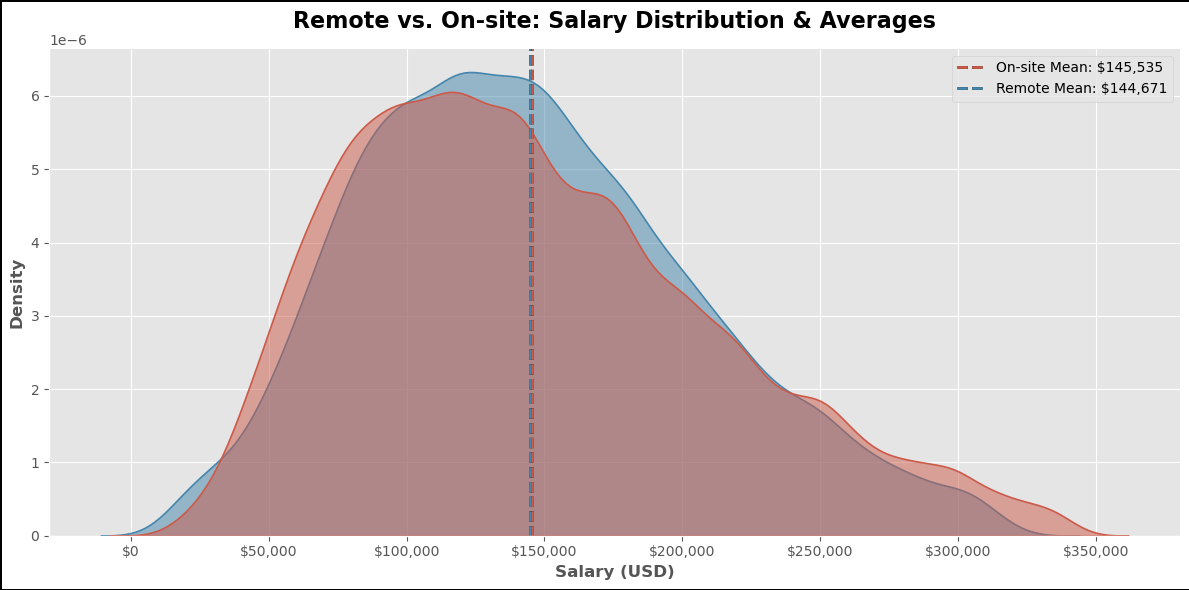

In [4]:
plot = sns.kdeplot(
    data = df,
    x = 'salary_in_usd',
    hue = 'work_mode',
    fill = True,
    palette = {'Remote': '#4586AC', 'On-site': '#CC5A49'},
    common_norm = False,
    alpha = 0.5,
    linewidth = 1.2
)

plot.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, loc: f'${int(x):,}'
    )
)

plot.figure.patch.set_linewidth(1)
plot.figure.patch.set_edgecolor('black')

mean_remote = df[df['work_mode'] == 'Remote']['salary_in_usd'].mean()
mean_onsite = df[df['work_mode'] == 'On-site']['salary_in_usd'].mean()

plt.axvline(
    mean_onsite, 
    linestyle = '--', 
    color = '#CC5A49', 
    linewidth = 2, 
    path_effects = [pe.withStroke(linewidth = 2, foreground = 'black')],
    label = f'On-site Mean: ${int(mean_onsite):,}'
)
plt.axvline(
    mean_remote, 
    linestyle = '--', 
    color = '#4586AC',
    linewidth = 2, 
    path_effects = [pe.withStroke(linewidth = 2, foreground = 'black')],
    label = f'Remote Mean: ${int(mean_remote):,}'
)

plt.title('Remote vs. On-site: Salary Distribution & Averages', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Salary (USD)', fontsize = 12, fontweight = 'bold')
plt.ylabel('Density', fontsize = 12, fontweight = 'bold')

plt.legend(loc = 'upper right', frameon = True)
sns.despine()

plt.tight_layout()

plt.savefig(
    r'plots/work_mode_density.png',
    edgecolor = plot.figure.get_edgecolor(),
    facecolor = plot.figure.get_facecolor()
)

plt.show()